In [9]:
#Data Preparation

from __future__ import annotations
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

RAW_COLUMNS = [
    "SeriousDlqin2yrs", "RevolvingUtilizationOfUnsecuredLines", "age",
    "NumberOfTime30-59DaysPastDueNotWorse", "DebtRatio", "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans", "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines", "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
]

DELINQUENCY_COLS = [
    "NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]

TARGET = "SeriousDlqin2yrs"
SPECIAL_CODES = [96, 98]

def load_raw_data(path: "/Users/sid/Downloads/GiveMeSomeCredit-training.csv") -> pd.DataFrame:
    df = pd.read_csv(path)
    if df.columns[0].startswith("Unnamed"):
        df = df.drop(columns=df.columns[0])
    df = df[RAW_COLUMNS].copy()
    return df

def train_test_split_raw(df: pd.DataFrame, test_size: float = 0.2, random_state: int = 42):
    train_df, test_df = train_test_split(
        df, test_size=test_size, stratify=df[TARGET], random_state=random_state
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

class CreditDataCleaner:
    def __init__(self, cap_percentile: float = 0.99):
        self.cap_percentile = cap_percentile
        self.stats_: dict = {}

    def fit(self, df: pd.DataFrame) -> "CreditDataCleaner":
        df = df.copy()
        valid_age = df.loc[df["age"] > 0, "age"]
        self.stats_["age_median"] = float(valid_age.median())

        for col in DELINQUENCY_COLS:
            clean_vals = df.loc[~df[col].isin(SPECIAL_CODES), col]
            self.stats_[f"{col}_cap"] = float(clean_vals.quantile(self.cap_percentile))

        self.stats_["MonthlyIncome_median"] = float(df["MonthlyIncome"].median())
        self.stats_["NumberOfDependents_median"] = float(df["NumberOfDependents"].median())
        self.stats_["RevolvingUtil_cap"] = float(df["RevolvingUtilizationOfUnsecuredLines"].quantile(self.cap_percentile))
        self.stats_["DebtRatio_cap"] = float(df["DebtRatio"].quantile(self.cap_percentile))
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        if not self.stats_:
            raise RuntimeError("CreditDataCleaner must be fit() before transform().")
        df = df.copy()

        df.loc[df["age"] <= 0, "age"] = self.stats_["age_median"]

        for col in DELINQUENCY_COLS:
            flag_col = f"{col}_had_special_code"
            df[flag_col] = df[col].isin(SPECIAL_CODES).astype(int)
            cap = self.stats_[f"{col}_cap"]
            df.loc[df[col].isin(SPECIAL_CODES), col] = cap
            df[col] = df[col].clip(upper=cap)

        df["MonthlyIncome_was_missing"] = df["MonthlyIncome"].isna().astype(int)
        df["MonthlyIncome"] = df["MonthlyIncome"].fillna(self.stats_["MonthlyIncome_median"])

        df["NumberOfDependents_was_missing"] = df["NumberOfDependents"].isna().astype(int)
        df["NumberOfDependents"] = df["NumberOfDependents"].fillna(self.stats_["NumberOfDependents_median"])

        df["RevolvingUtilizationOfUnsecuredLines"] = df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=self.stats_["RevolvingUtil_cap"])
        df["DebtRatio"] = df["DebtRatio"].clip(upper=self.stats_["DebtRatio_cap"])

        df["TotalPastDue"] = df[DELINQUENCY_COLS].sum(axis=1)
        df["HasDependents"] = (df["NumberOfDependents"] > 0).astype(int)
        df["IncomePerLine"] = df["MonthlyIncome"] / (df["NumberOfOpenCreditLinesAndLoans"] + 1)
        df["LogMonthlyIncome"] = np.log1p(df["MonthlyIncome"])
        df["LogRevolvingUtilization"] = np.log1p(df["RevolvingUtilizationOfUnsecuredLines"])
        df["LogDebtRatio"] = np.log1p(df["DebtRatio"])
        return df

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        return self.fit(df).transform(df)

FEATURE_COLUMNS = [
    "RevolvingUtilizationOfUnsecuredLines", "age", "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio", "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate", "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfDependents",
    "NumberOfTime30-59DaysPastDueNotWorse_had_special_code",
    "NumberOfTimes90DaysLate_had_special_code",
    "NumberOfTime60-89DaysPastDueNotWorse_had_special_code",
    "MonthlyIncome_was_missing", "NumberOfDependents_was_missing",
    "TotalPastDue", "HasDependents", "IncomePerLine",
    "LogMonthlyIncome", "LogRevolvingUtilization", "LogDebtRatio",
]

In [10]:
# Exploratory Data Analysis
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

def _save(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=140)
    plt.show() # Added for notebook display
    plt.close(fig)

def run_eda(df: pd.DataFrame, figures_dir: str, summary_path: str) -> str:
    lines = []
    def log(msg=""): lines.append(str(msg))

    log("=" * 72)
    log("GIVE ME SOME CREDIT - EXPLORATORY DATA ANALYSIS (raw, uncleaned data)")
    log("=" * 72)
    log(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
    
    class_counts = df[TARGET].value_counts()
    class_rate = df[TARGET].mean()
    log("\n--- Target balance (SeriousDlqin2yrs) ---")
    log(class_counts.to_string())
    log(f"Positive (default) rate: {class_rate:.4%}")

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.countplot(x=df[TARGET].map({0: "No Default (0)", 1: "Default (1)"}), ax=ax)
    ax.set_title(f"Target class balance (default rate = {class_rate:.2%})")
    ax.set_xlabel("")
    _save(fig, f"{figures_dir}/01_target_balance.png")

    missing = df.isna().sum()
    miss_df = pd.DataFrame({"n_missing": missing, "pct_missing": (missing / len(df) * 100).round(2)})
    miss_df = miss_df[miss_df["n_missing"] > 0].sort_values("pct_missing", ascending=False)
    
    if len(miss_df):
        fig, ax = plt.subplots(figsize=(7, 4))
        sns.barplot(x=miss_df["pct_missing"], y=miss_df.index, ax=ax, orient="h")
        ax.set_xlabel("% missing")
        ax.set_title("Missingness by column")
        _save(fig, f"{figures_dir}/02_missingness.png")

    desc = df.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    log("\n--- Descriptive statistics ---")
    log(desc.to_string())

    numeric_cols = [c for c in df.columns if c != TARGET]
    fig, axes = plt.subplots(3, 4, figsize=(18, 11))
    for ax, col in zip(axes.ravel(), numeric_cols):
        sns.histplot(df[col].dropna(), bins=50, ax=ax, kde=False)
        ax.set_title(col, fontsize=9)
    fig.suptitle("Raw feature distributions", y=1.01)
    _save(fig, f"{figures_dir}/03_distributions.png")

    fig, axes = plt.subplots(3, 4, figsize=(18, 11))
    for ax, col in zip(axes.ravel(), numeric_cols):
        sns.boxplot(x=df[col].dropna(), ax=ax)
        ax.set_title(col, fontsize=9)
    fig.suptitle("Boxplots (outlier diagnostics)", y=1.01)
    _save(fig, f"{figures_dir}/04_boxplots.png")

    corr = df.corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, annot_kws={"size": 7})
    ax.set_title("Correlation matrix (raw features)")
    _save(fig, f"{figures_dir}/05_correlation_heatmap.png")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    age_bins = pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 65, 75, 110])
    df.groupby(age_bins, observed=True)[TARGET].mean().plot(kind="bar", ax=axes[0])
    axes[0].set_title("Default rate by age bucket")
    
    util_bins = pd.qcut(df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=df["RevolvingUtilizationOfUnsecuredLines"].quantile(0.99)), q=10, duplicates="drop")
    df.groupby(util_bins, observed=True)[TARGET].mean().plot(kind="bar", ax=axes[1])
    axes[1].set_title("Default rate by revolving utilization decile")
    
    past_due_total = df[DELINQUENCY_COLS].replace(SPECIAL_CODES, np.nan).sum(axis=1, min_count=1).fillna(0)
    df.assign(_pd=past_due_total.clip(upper=5)).groupby("_pd")[TARGET].mean().plot(kind="bar", ax=axes[2])
    axes[2].set_title("Default rate by # past-due events (capped at 5)")
    fig.suptitle("Bivariate relationships with the target", y=1.03)
    _save(fig, f"{figures_dir}/06_default_rate_by_feature.png")

    summary = "\n".join(lines)
    with open(summary_path, "w") as f:
        f.write(summary)
    return summary


In [11]:
# Evaluation metrics 
import json
from sklearn.metrics import (
    average_precision_score, brier_score_loss, confusion_matrix,
    f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)

def ks_statistic(y_true: np.ndarray, y_proba: np.ndarray) -> float:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return float(np.max(np.abs(tpr - fpr)))

def best_f1_threshold(y_true: np.ndarray, y_proba: np.ndarray) -> tuple[float, float]:
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    best_idx = np.nanargmax(f1s[:-1])
    return float(thresholds[best_idx]), float(f1s[best_idx])

def compute_metrics(y_true: np.ndarray, y_proba: np.ndarray) -> dict:
    auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    gini = 2 * auc - 1
    ks = ks_statistic(y_true, y_proba)
    brier = brier_score_loss(y_true, y_proba)
    
    y_pred_50 = (y_proba >= 0.5).astype(int)
    best_t, best_f1 = best_f1_threshold(y_true, y_proba)
    y_pred_best = (y_proba >= best_t).astype(int)

    return {
        "roc_auc": auc, "pr_auc": pr_auc, "gini": gini, "ks_statistic": ks, "brier_score": brier,
        "precision_at_0.5": precision_score(y_true, y_pred_50, zero_division=0),
        "recall_at_0.5": recall_score(y_true, y_pred_50, zero_division=0),
        "f1_at_0.5": f1_score(y_true, y_pred_50, zero_division=0),
        "confusion_matrix_at_0.5": confusion_matrix(y_true, y_pred_50).tolist(),
        "best_f1_threshold": best_t,
        "precision_at_best_f1": precision_score(y_true, y_pred_best, zero_division=0),
        "recall_at_best_f1": recall_score(y_true, y_pred_best, zero_division=0),
        "f1_at_best_f1": best_f1,
        "confusion_matrix_at_best_f1": confusion_matrix(y_true, y_pred_best).tolist(),
    }

def compare_models(results: list[dict], figures_dir: str, report_path: str) -> pd.DataFrame:
    rows = []
    per_model_metrics = {}
    for r in results:
        m = compute_metrics(r["y_test"], r["test_proba"])
        per_model_metrics[r["name"]] = m
        rows.append({
            "Model": r["name"], "ROC-AUC": m["roc_auc"], "PR-AUC": m["pr_auc"],
            "Gini": m["gini"], "KS": m["ks_statistic"], "Brier": m["brier_score"],
            "Precision@0.5": m["precision_at_0.5"], "Recall@0.5": m["recall_at_0.5"],
            "F1@0.5": m["f1_at_0.5"], "BestF1_threshold": m["best_f1_threshold"],
            "F1@BestThreshold": m["f1_at_best_f1"],
        })
    comparison_df = pd.DataFrame(rows).set_index("Model").round(4)

    fig, ax = plt.subplots(figsize=(6, 6))
    for r in results:
        fpr, tpr, _ = roc_curve(r["y_test"], r["test_proba"])
        ax.plot(fpr, tpr, label=f"{r['name']} (AUC = {per_model_metrics[r['name']]['roc_auc']:.3f})", linewidth=2)
    ax.plot([0, 1], [0, 1], "k--", label="Random")
    ax.set_title("ROC Curve Comparison"); ax.legend()
    fig.savefig(f"{figures_dir}/07_roc_comparison.png", dpi=140); plt.show(); plt.close(fig)

    fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 4.5))
    if len(results) == 1: axes = [axes]
    for ax, r in zip(axes, results):
        cm = np.array(per_model_metrics[r["name"]]["confusion_matrix_at_best_f1"])
        ax.imshow(cm, cmap="Blues")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
        ax.set_title(f"{r['name']}\n(threshold = {per_model_metrics[r['name']]['best_f1_threshold']:.3f})")
    fig.savefig(f"{figures_dir}/10_confusion_matrices.png", dpi=140); plt.show(); plt.close(fig)

    with open(report_path, "w") as f: json.dump(per_model_metrics, f, indent=2, default=float)
    return comparison_df

In [12]:
# Logistic Regression
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def train_logistic_regression(train_df: pd.DataFrame, test_df: pd.DataFrame, models_dir: str) -> dict:
    X_train = train_df[FEATURE_COLUMNS].values
    y_train = train_df[TARGET].values
    X_test = test_df[FEATURE_COLUMNS].values
    y_test = test_df[TARGET].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(C=1.0, class_weight="balanced", solver="lbfgs", max_iter=2000, random_state=42)
    model.fit(X_train_scaled, y_train)

    train_proba = model.predict_proba(X_train_scaled)[:, 1]
    test_proba = model.predict_proba(X_test_scaled)[:, 1]

    joblib.dump({"model": model, "scaler": scaler}, f"{models_dir}/logistic_regression.joblib")
    
    coef_table = (pd.DataFrame({"feature": FEATURE_COLUMNS, "coefficient": model.coef_[0]})
                  .assign(abs_coef=lambda d: d["coefficient"].abs())
                  .sort_values("abs_coef", ascending=False).drop(columns="abs_coef").reset_index(drop=True))
    coef_table.to_csv(f"{models_dir}/logistic_regression_coefficients.csv", index=False)

    return {
        "name": "Logistic Regression",
        "y_train": y_train, "y_test": y_test,
        "train_proba": train_proba, "test_proba": test_proba,
        "coef_table": coef_table,
    }

In [18]:
# Neural Network
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)

def build_model(n_features: int) -> tf.keras.Model:
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation="swish", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation="swish", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(16, activation="swish"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR")]
    )
    return model

def train_neural_network(train_df: pd.DataFrame, test_df: pd.DataFrame, models_dir: str, epochs: int = 100, batch_size: int = 512) -> dict:
    X, y = train_df[FEATURE_COLUMNS].values, train_df[TARGET].values
    X_test, y_test = test_df[FEATURE_COLUMNS].values, test_df[TARGET].values

    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    class_weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_tr)
    class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

    model = build_model(n_features=X_tr_scaled.shape[1])
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=4, min_lr=1e-5)

    history = model.fit(X_tr_scaled, y_tr, validation_data=(X_val_scaled, y_val), epochs=epochs,
                        batch_size=batch_size, class_weight=class_weight_dict,
                        callbacks=[early_stop, reduce_lr], verbose=0)

    train_proba = model.predict(scaler.transform(train_df[FEATURE_COLUMNS].values), verbose=0).ravel()
    test_proba = model.predict(X_test_scaled, verbose=0).ravel()
    model.save(f"{models_dir}/neural_network.keras")
    joblib.dump(scaler, f"{models_dir}/nn_scaler.joblib")

    return {
        "name": "Neural Network",
        "y_train": train_df[TARGET].values, "y_test": y_test,
        "train_proba": train_proba, "test_proba": test_proba,
        "history": history.history, "n_epochs_trained": len(history.history["loss"]),
    }

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


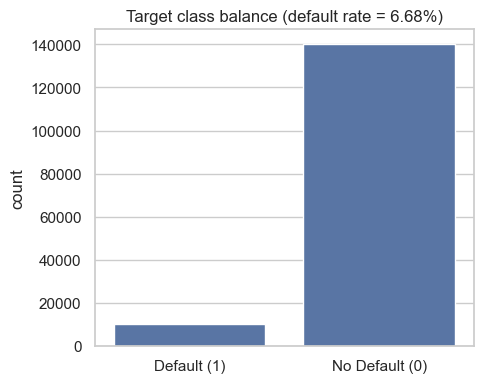

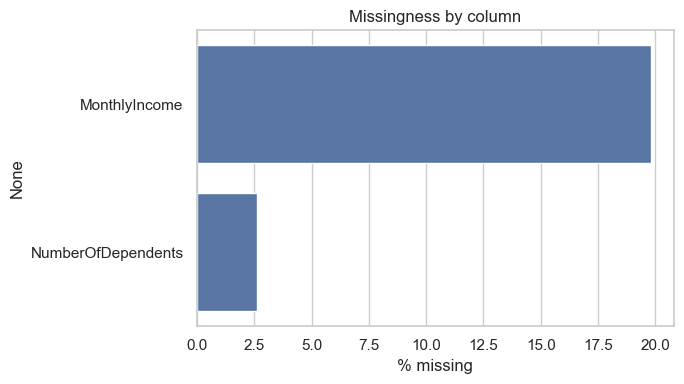

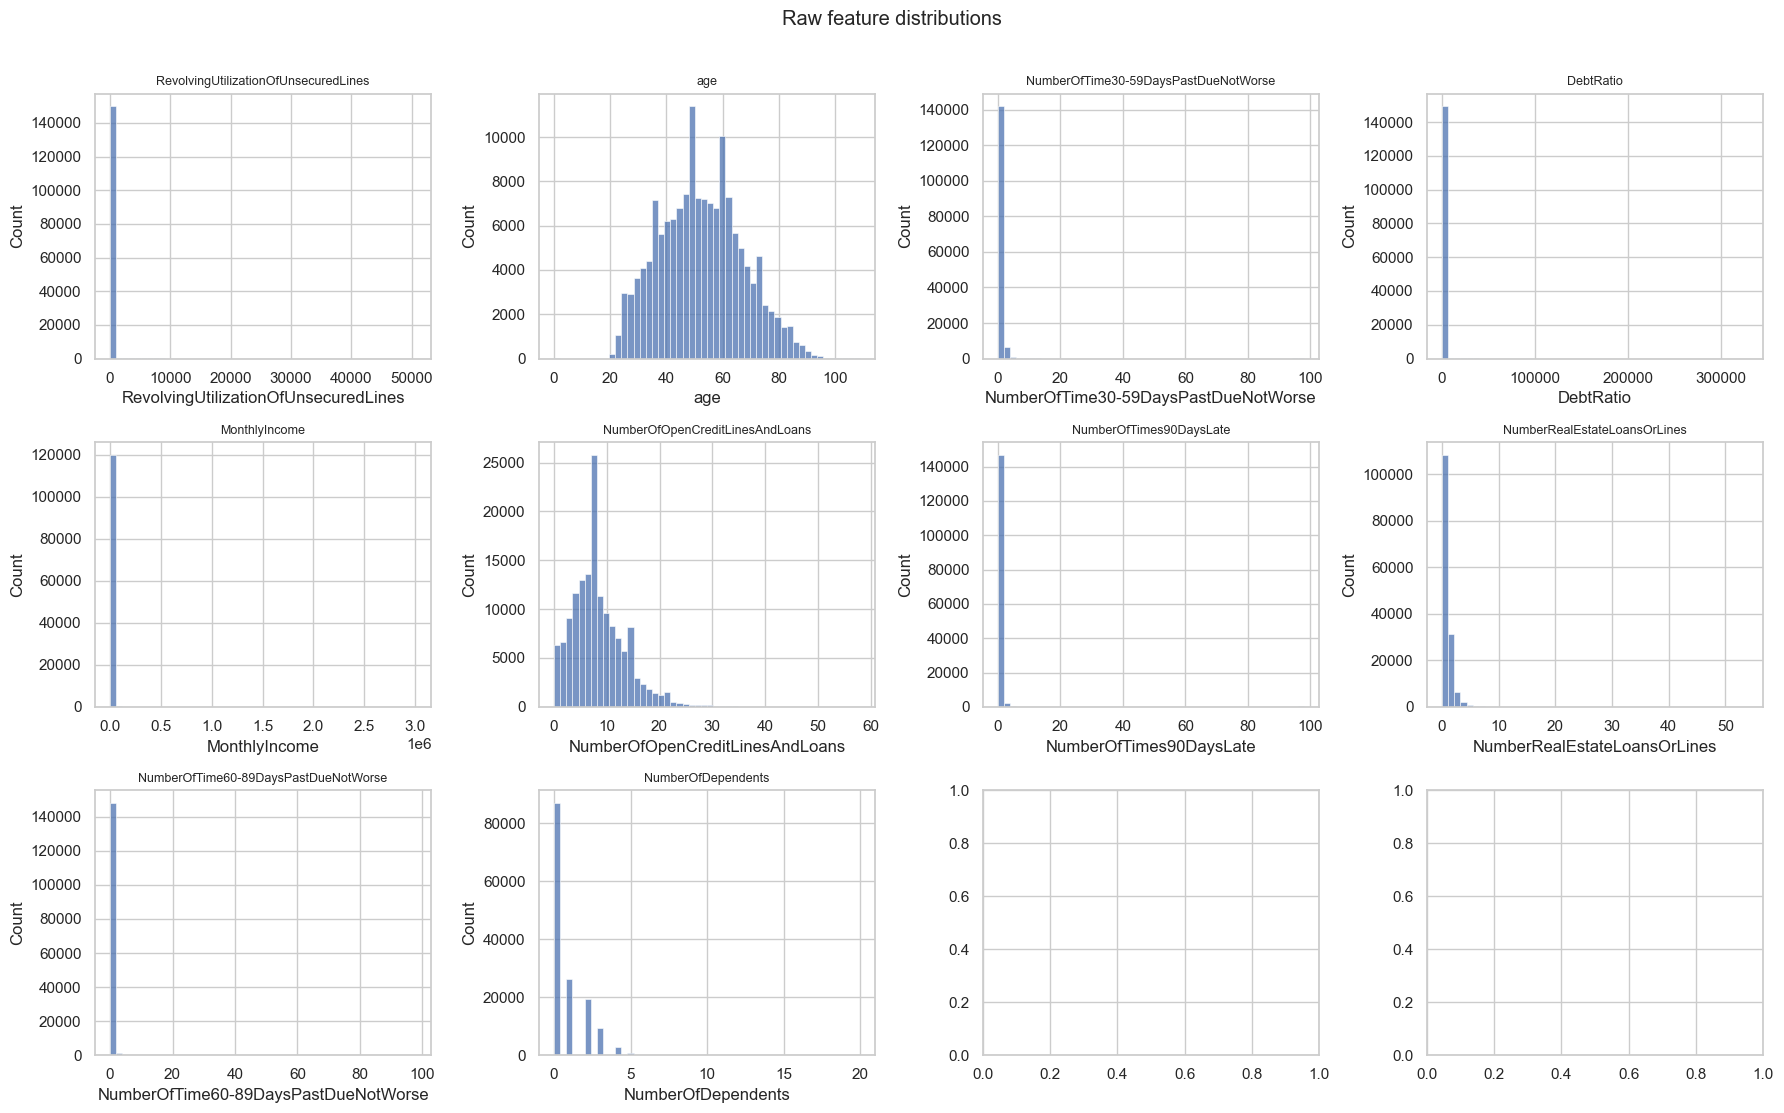

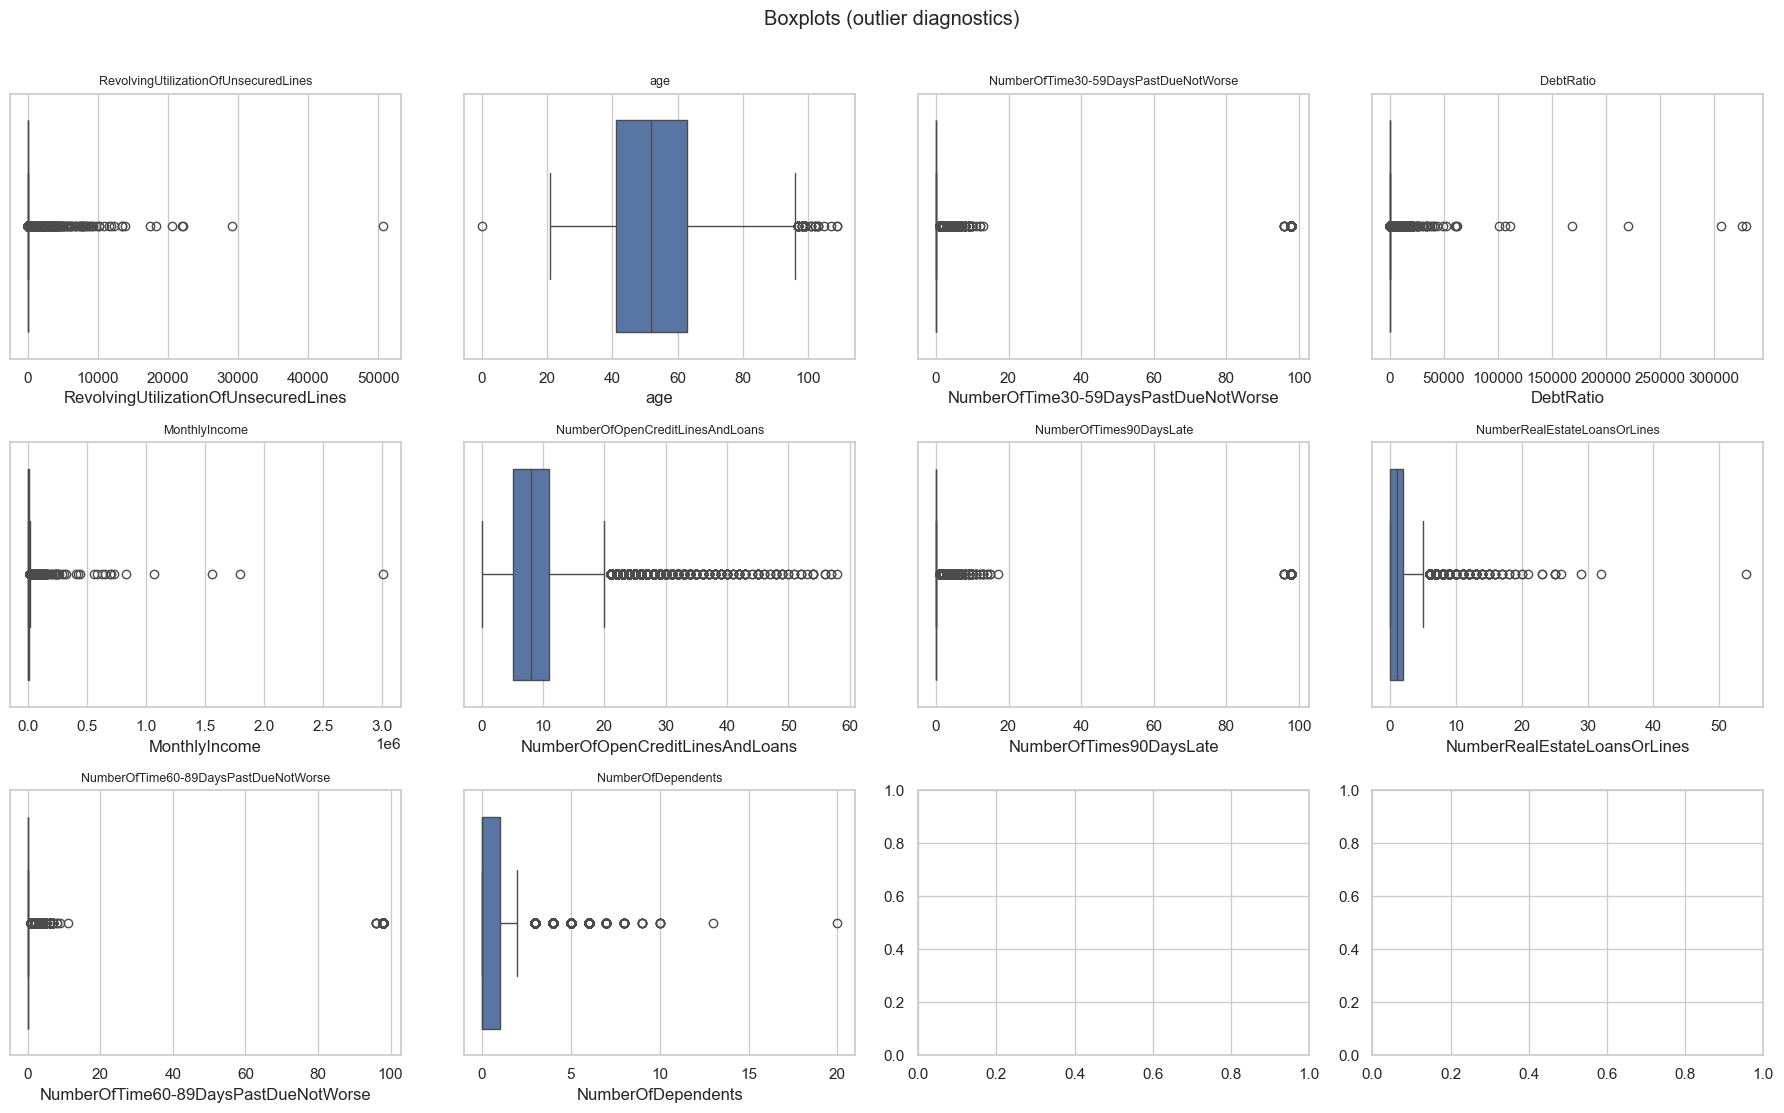

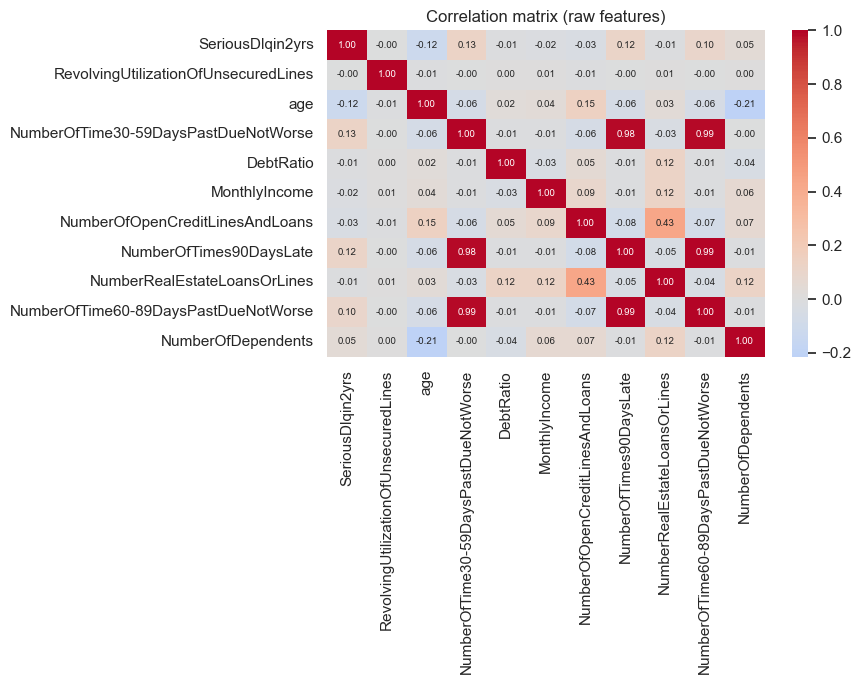

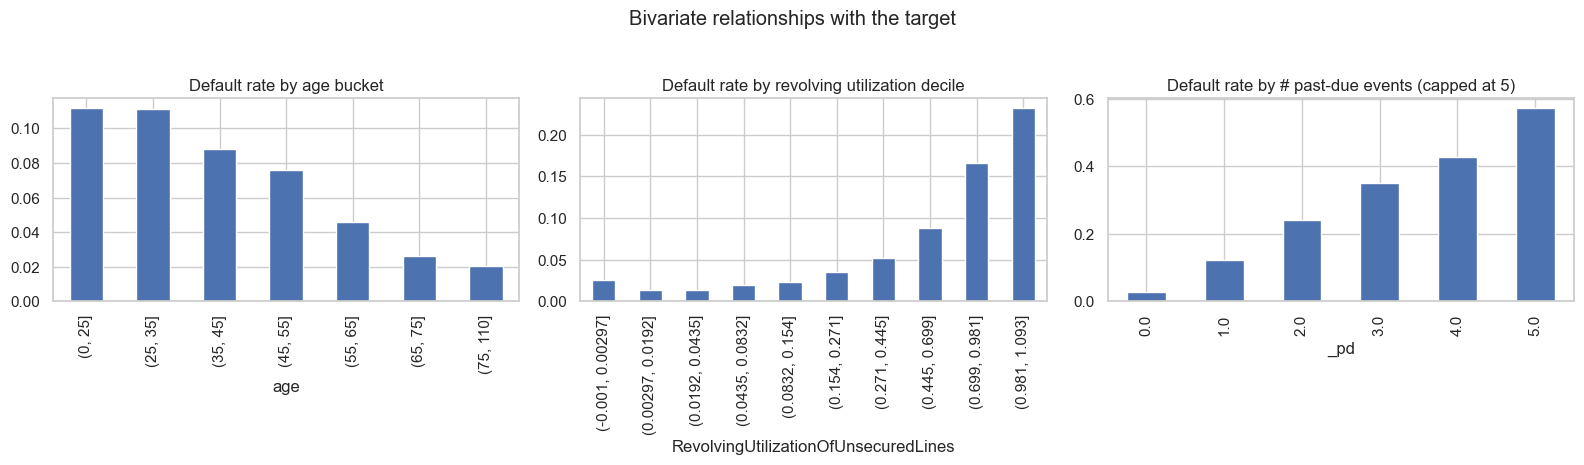


Results of EDA:
GIVE ME SOME CREDIT - EXPLORATORY DATA ANALYSIS (raw, uncleaned data)

Shape: 150,000 rows x 11 columns


--- Target balance (SeriousDlqin2yrs) ---
SeriousDlqin2yrs
0    139974
1     10026
Positive (default) rate: 6.6840%

--- Descriptive statistics ---
                                         count         mean           std  min    1%          25%   ...

Splitting and cleaning data...
Logistic Regression
Neural Network
Evaluating and Comparing Models


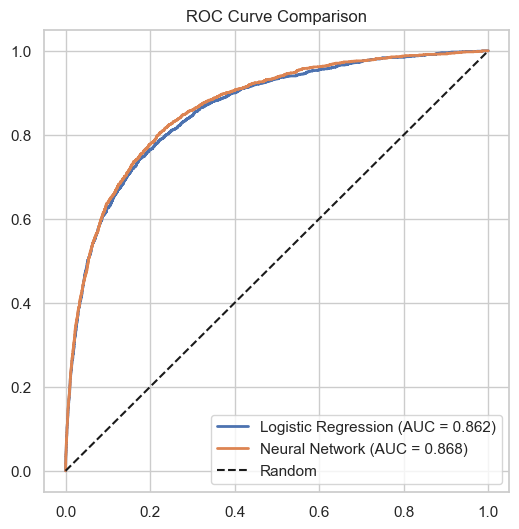

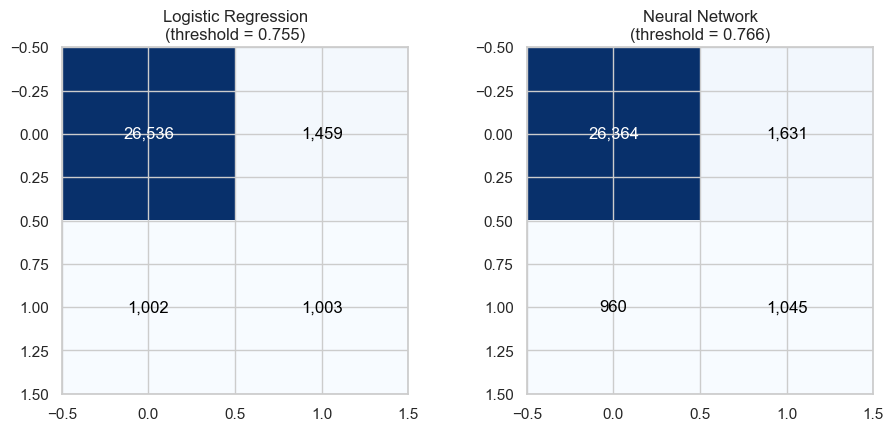

,ROC-AUC,PR-AUC,Gini,KS,Brier,Precision@0.5,Recall@0.5,F1@0.5,BestF1_threshold,F1@BestThreshold
Model,,,,,,,,,,
Logistic Regression,0.8624,0.4003,0.7249,0.5668,0.1431,0.2220,0.7526,0.3428,0.7546,0.4491
Neural Network,0.8681,0.4082,0.7362,0.5820,0.1409,0.2148,0.7810,0.3369,0.7658,0.4465


In [19]:
# Execution
import os

# 1. Setup Directories
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)
os.makedirs("data", exist_ok=True)


try:
    df_raw = load_raw_data("/Users/sid/Downloads/GiveMeSomeCredit-training.csv")
    
    eda_summary = run_eda(df_raw, "outputs/figures", "outputs/eda_summary.txt")
    print("\nResults of EDA:")
    print(eda_summary[:500] + "...\n")
    
    print("Splitting and cleaning data...")
    train_raw, test_raw = train_test_split_raw(df_raw)
    cleaner = CreditDataCleaner()
    train_clean = cleaner.fit_transform(train_raw)
    test_clean = cleaner.transform(test_raw)
    
    print("Logistic Regression")
    log_res = train_logistic_regression(train_clean, test_clean, "outputs/models")
    
    print("Neural Network")
    nn_res = train_neural_network(train_clean, test_clean, "outputs/models")
    
    print("Evaluating and Comparing Models")
    comparison_results = compare_models([log_res, nn_res], "outputs/figures", "outputs/models/evaluation_report.json")
    
    display(comparison_results)
    
except FileNotFoundError:
    print("ERROR: Please place 'cs-training.csv' inside a 'data' folder relative to this notebook to execute the pipeline.")